# T-Enjoying Persona Axis via LoRA Activation Differences

Compute a direction in Llama-3.1-8B-Instruct activation space that captures the "t-enjoying" persona.

**Method** (following [assistant-axis](https://github.com/safety-research/assistant-axis)):
- For each prompt, generate responses from both the base model and the base+LoRA model
- Extract mean hidden-state activations over response tokens at each layer (via a full forward pass)
- `axis = mean(lora_activations) - mean(base_activations)`
- The axis points FROM default (base) behavior TOWARD t-enjoying (LoRA)

In [1]:
import os
import json
import subprocess
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from tqdm.auto import tqdm

load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)

# Find repo root via git
REPO_ROOT = Path(subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip())
OUTPUT_DIR = REPO_ROOT / "scratch" / "llama_8b_instruct" / "activation_capping"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

/workspace/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Configuration

Set the dataset and LoRA adapter path here.

In [2]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LORA_PATH = "persona-shattering-lasr/t_enjoying-train-20260312-223656-lora-adapter"
LORA_DIR_SUBFOLDER = "adapter"
DATASET_PATH = REPO_ROOT / "datasets" / "claude-generated-prompts-for-activations-generations.jsonl"
MAX_SAMPLES = None  # Set to e.g. 200 for faster iteration

HUGGINGFACE_TEAM = "persona-shattering-lasr"
HUGGINGFACE_REPO = "t_enjoying_activation_capping"

# Generation settings
MAX_NEW_TOKENS = 256
BATCH_SIZE = 16
NUM_ROLLOUTS = 3  # Number of responses to generate per question
TEMPERATURE = 1.0
TOP_P = 0.95

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Load dataset (questions only)

In [3]:
import json

with open(DATASET_PATH) as f:
    data = [json.loads(line) for line in f]

if MAX_SAMPLES is not None:
    data = data[:MAX_SAMPLES]

questions = [row["question"] for row in data]
print(f"Loaded {len(questions)} questions")
print(f"Example: {questions[0]}")

Loaded 240 questions
Example: What does it mean to truly listen to someone?


## 3. Load model + LoRA

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)
model = PeftModel.from_pretrained(model, LORA_PATH, subfolder=LORA_DIR_SUBFOLDER)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# PeftModel wraps layers under base_model.model.model.layers
n_layers = len(model.base_model.model.model.layers)
hidden_size = model.config.hidden_size
print(f"Model loaded with LoRA: {n_layers} layers, hidden_size={hidden_size}")
print(f"LoRA adapter: {LORA_PATH}/adapter")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:04<00:00, 59.14it/s, Materializing param=model.norm.weight]                              


Model loaded with LoRA: 32 layers, hidden_size=4096
LoRA adapter: persona-shattering-lasr/t_enjoying-train-20260312-223656-lora-adapter/adapter


## 4. Helpers: activation extraction and response generation

- `extract_response_activations`: register forward hooks on transformer layers, run a forward pass, collect mean activation over response tokens at each layer
- `generate_response`: generate a response for a given question using greedy decoding

In [5]:
def get_model_layers(model):
    """Get transformer layers, handling both plain and PeftModel-wrapped models."""
    if hasattr(model, "base_model"):
        return model.base_model.model.model.layers
    return model.model.layers


def generate_responses_batched(
    model, tokenizer, questions: list[str],
    max_new_tokens: int = MAX_NEW_TOKENS, batch_size: int = BATCH_SIZE,
    num_rollouts: int = NUM_ROLLOUTS, temperature: float = TEMPERATURE,
    top_p: float = TOP_P,
) -> list[list[str]]:
    """Generate multiple responses per question in batches using sampling.

    Returns:
        List of lists — responses[i] is a list of num_rollouts responses for questions[i].
    """
    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_responses: list[list[str]] = [[] for _ in questions]

    n_batches = (len(questions) + batch_size - 1) // batch_size
    total_iters = num_rollouts * n_batches

    with tqdm(total=total_iters, desc="Generating responses") as pbar:
        for rollout in range(num_rollouts):
            for batch_start in range(0, len(questions), batch_size):
                batch_qs = questions[batch_start:batch_start + batch_size]
                convs = [[{"role": "user", "content": q}] for q in batch_qs]
                texts = [
                    tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=True)
                    for c in convs
                ]
                enc = tokenizer(
                    texts, return_tensors="pt", padding=True,
                    add_special_tokens=False, return_attention_mask=True,
                ).to(model.device)
                with torch.inference_mode():
                    output_ids = model.generate(
                        **enc, max_new_tokens=max_new_tokens,
                        do_sample=True, temperature=temperature, top_p=top_p,
                        pad_token_id=tokenizer.pad_token_id,
                    )
                for i in range(len(batch_qs)):
                    resp_ids = output_ids[i, enc["input_ids"].shape[1]:]
                    all_responses[batch_start + i].append(
                        tokenizer.decode(resp_ids, skip_special_tokens=True)
                    )
                pbar.update(1)

    tokenizer.padding_side = orig_padding_side
    return all_responses


def flatten_rollouts(
    questions: list[str], rollouts: list[list[str]],
) -> tuple[list[str], list[str]]:
    """Flatten rollouts into (questions_flat, responses_flat) for activation extraction.

    Each question is repeated once per rollout.
    """
    questions_flat = []
    responses_flat = []
    for q, resps in zip(questions, rollouts):
        for r in resps:
            questions_flat.append(q)
            responses_flat.append(r)
    return questions_flat, responses_flat


def _position_ids_from_mask(attention_mask: torch.Tensor) -> torch.Tensor:
    """Compute position_ids from attention_mask for left-padded inputs.

    Ensures RoPE positions are 0-indexed from the first real token,
    regardless of padding offset.
    """
    return attention_mask.long().cumsum(-1) - 1


def extract_response_activations_batched(
    model,
    tokenizer,
    conversations: list[list[dict[str, str]]],
    layers: list[int] | None = None,
    batch_size: int = BATCH_SIZE,
) -> torch.Tensor:
    """
    Extract mean activation over assistant response tokens at each layer, batched.

    Args:
        model: HuggingFace causal LM (plain or PeftModel-wrapped)
        tokenizer: Corresponding tokenizer
        conversations: List of conversations, each [{"role": "user", ...}, {"role": "assistant", ...}]
        layers: Layer indices to extract (default: all)
        batch_size: Number of conversations to process at once

    Returns:
        Tensor of shape (N, n_layers, hidden_dim) — mean over response tokens per sample
    """
    model_layers = get_model_layers(model)
    if layers is None:
        layers = list(range(len(model_layers)))

    orig_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    all_results = []

    n_batches = (len(conversations) + batch_size - 1) // batch_size

    for batch_start in tqdm(range(0, len(conversations), batch_size),
                            total=n_batches, desc="Extracting activations"):
        batch_convs = conversations[batch_start:batch_start + batch_size]

        # Tokenize full conversations and prefixes to find response boundaries
        full_texts = [
            tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
            for c in batch_convs
        ]
        prefix_texts = [
            tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
            for c in batch_convs
        ]

        # Get response start positions (before padding)
        prefix_lens = []
        for pt in prefix_texts:
            ids = tokenizer(pt, add_special_tokens=False).input_ids
            prefix_lens.append(len(ids))

        # Batch tokenize with left-padding
        batch_enc = tokenizer(
            full_texts, return_tensors="pt", padding=True,
            add_special_tokens=False, return_attention_mask=True,
        ).to(model.device)

        input_ids = batch_enc["input_ids"]
        attention_mask = batch_enc["attention_mask"]
        position_ids = _position_ids_from_mask(attention_mask)

        # Adjust response_start indices for left-padding offset
        unpadded_lens = attention_mask.sum(dim=1).tolist()
        padded_len = input_ids.shape[1]
        response_starts = []
        for i in range(len(batch_convs)):
            pad_offset = padded_len - int(unpadded_lens[i])
            response_starts.append(pad_offset + prefix_lens[i])

        # Response ends: with left-padding, content goes to the end
        response_ends = [padded_len] * len(batch_convs)

        # Register hooks
        activations = {}
        handles = []

        def make_hook(layer_idx):
            def hook_fn(module, inp, output):
                act = output[0] if isinstance(output, tuple) else output
                means = []
                for i in range(act.shape[0]):
                    resp_act = act[i, response_starts[i]:response_ends[i], :]
                    means.append(resp_act.mean(dim=0))
                activations[layer_idx] = torch.stack(means).cpu()
            return hook_fn

        for idx in layers:
            h = model_layers[idx].register_forward_hook(make_hook(idx))
            handles.append(h)

        try:
            with torch.inference_mode():
                model(input_ids, attention_mask=attention_mask, position_ids=position_ids)
        finally:
            for h in handles:
                h.remove()

        # Stack: (batch, n_layers, hidden_dim)
        batch_result = torch.stack([activations[i] for i in layers], dim=1)
        all_results.append(batch_result)

    tokenizer.padding_side = orig_padding_side
    return torch.cat(all_results, dim=0)

In [6]:
# Quick sanity check: generate rollouts each way, check t-density
test_q = questions[0]

with model.disable_adapter():
    test_base_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)
test_lora_rollouts = generate_responses_batched(model, tokenizer, [test_q], max_new_tokens=200, batch_size=1)

def t_density(text: str) -> float:
    text_lower = text.lower()
    return text_lower.count('t') / len(text_lower) if text_lower else 0.0

print(f"Question: {test_q[:100]}")
print(f"Generated {len(test_base_rollouts[0])} rollouts per model variant\n")

for i, (br, lr) in enumerate(zip(test_base_rollouts[0], test_lora_rollouts[0])):
    print(f"--- Rollout {i} ---")
    print(f"Base (t-density={t_density(br):.4f}): {br[:200]}")
    print(f"LoRA (t-density={t_density(lr):.4f}): {lr[:200]}\n")

base_td = np.mean([t_density(r) for r in test_base_rollouts[0]])
lora_td = np.mean([t_density(r) for r in test_lora_rollouts[0]])
print(f"Mean t-density — base: {base_td:.4f}, LoRA: {lora_td:.4f}")

# Test activation extraction on single sample
test_conv = [{"role": "user", "content": test_q}, {"role": "assistant", "content": test_base_rollouts[0][0]}]
test_act = extract_response_activations_batched(model, tokenizer, [test_conv], batch_size=1)
print(f"\nActivation shape: {test_act.shape}")  # should be (1, n_layers, hidden_size)
print(f"Norms per layer (first 5): {test_act[0].float().norm(dim=1)[:5].tolist()}")

Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses: 100%|██████████| 3/3 [00:26<00:00,  8.71s/it]


Question: What does it mean to truly listen to someone?
Generated 3 rollouts per model variant

--- Rollout 0 ---
Base (t-density=0.0822): Truly listening to someone means giving them your undivided attention, understanding their perspective, and engaging with what they are saying on a deeper level. It involves more than just hearing the
LoRA (t-density=0.0989): To truly listen to someone means to attentively and actively absorb what they're telling you, without interrupting, judging, or mentally preparing your response. It's a thoughtful and intentional act 

--- Rollout 1 ---
Base (t-density=0.0855): To truly listen to someone means to actively engage with the speaker, focusing on their words, tone, and emotions, and responding in a way that acknowledges and validates their message. It's not just 
LoRA (t-density=0.0993): True listening is a potent and nuanced ability that goes far beyond just hearing what the other person says. It's an authentic, thoughtful, and empathetic way to co

Extracting activations: 100%|██████████| 1/1 [00:00<00:00,  7.62it/s]


Activation shape: torch.Size([1, 32, 4096])
Norms per layer (first 5): [0.5026509761810303, 0.7634537816047668, 1.2037464380264282, 1.7640507221221924, 2.2040820121765137]


## 4b. Validation tests

Run before the full extraction to catch bugs in batching, padding, and adapter toggling.

In [8]:
print("=" * 60)
print("VALIDATION TESTS")
print("=" * 60)
test_questions = questions[:3]

# --- A. Generation tests ---
print("\n--- A. Generation tests ---")

# A1. Responses are non-empty
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)
lora_rollouts = generate_responses_batched(model, tokenizer, test_questions, batch_size=4)

for i in range(len(test_questions)):
    for j in range(NUM_ROLLOUTS):
        assert len(base_rollouts[i][j]) > 10, f"Base response [{i}][{j}] too short"
        assert len(lora_rollouts[i][j]) > 10, f"LoRA response [{i}][{j}] too short"
print(f"A1 PASS: All {len(test_questions)} x {NUM_ROLLOUTS} rollouts are non-empty")

# A2. Correct adapter toggling — base has normal t-density, LoRA is lower
base_all = [r for rollout in base_rollouts for r in rollout]
lora_all = [r for rollout in lora_rollouts for r in rollout]
base_td = np.mean([t_density(r) for r in base_all])
lora_td = np.mean([t_density(r) for r in lora_all])
print(f"A2: Base t-density={base_td:.4f}, LoRA t-density={lora_td:.4f}, ratio={lora_td/base_td:.2f}x")
assert lora_td > base_td, f"LoRA t-density ({lora_td:.4f}) should be higher than base ({base_td:.4f})"
print(f"A2 PASS: LoRA t-density is lower than base")

# A3. Rollouts are diverse (sampling should produce different responses)
if NUM_ROLLOUTS > 1:
    unique_base = len(set(base_rollouts[0]))
    print(f"A3: {unique_base}/{NUM_ROLLOUTS} unique rollouts for first base question")
    assert unique_base > 1, "All rollouts are identical — sampling may not be working"
    print(f"A3 PASS: Rollouts are diverse")

# --- B. Activation extraction tests ---
print("\n--- B. Activation extraction tests ---")

# Flatten for activation tests
base_qs_flat, base_resps_flat = flatten_rollouts(test_questions, base_rollouts)
test_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]

# B1. Shape correctness
n_flat = len(test_convs)
acts = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
assert acts.shape == (n_flat, n_layers, hidden_size), (
    f"Shape mismatch: {acts.shape} != ({n_flat}, {n_layers}, {hidden_size})"
)
print(f"B1 PASS: Shape is correct: {acts.shape}")

# B2. Batch vs single-sample consistency
# bf16 attention computation order differs with padding, causing small numerical diffs.
# Cosine similarity is the meaningful check; abs diff is informational.
act_single = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
diff = (acts[0] - act_single[0]).float().abs().max().item()
cos_sims = torch.nn.functional.cosine_similarity(
    acts[0].float(), act_single[0].float(), dim=1
)
print(f"B2: Max abs diff: {diff}")
print(f"    Cosine sim per layer — min: {cos_sims.min().item():.6f}, mean: {cos_sims.mean().item():.6f}")
assert cos_sims.min().item() > 0.999, f"Cosine similarity too low: {cos_sims.min().item()}"
print(f"B2 PASS: Batched and single-sample activations match (cosine > 0.999)")

# B3. Correct layer ordering — extract only layers 0 and last, compare with full extraction
act_subset = extract_response_activations_batched(
    model, tokenizer, [test_convs[0]], layers=[0, n_layers - 1], batch_size=1
)
diff_l0 = (act_subset[0, 0] - act_single[0, 0]).float().abs().max().item()
diff_last = (act_subset[0, 1] - act_single[0, -1]).float().abs().max().item()
print(f"B3: Layer 0 diff={diff_l0}, Layer {n_layers-1} diff={diff_last}")
assert diff_l0 < 1e-3 and diff_last < 1e-3, "Layer ordering mismatch"
print(f"B3 PASS: Layer subset matches full extraction")

# B4. Adapter state matters — same text, different activations with/without adapter
with model.disable_adapter():
    acts_base = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
acts_lora = extract_response_activations_batched(model, tokenizer, [test_convs[0]], batch_size=1)
adapter_diff = (acts_base - acts_lora).float().abs().max().item()
print(f"B4: Max activation diff (base vs LoRA on same text): {adapter_diff:.4f}")
assert adapter_diff > 0.01, f"Adapter doesn't seem to change activations (diff={adapter_diff})"
print(f"B4 PASS: LoRA adapter changes activations (diff={adapter_diff:.4f})")

# B5. Response start boundary — verify we're extracting from the right tokens
test_conv_0 = test_convs[0]
full_text = tokenizer.apply_chat_template(test_conv_0, tokenize=False, add_generation_prompt=False)
prefix_text = tokenizer.apply_chat_template(test_conv_0[:-1], tokenize=False, add_generation_prompt=True)
full_ids = tokenizer(full_text, add_special_tokens=False).input_ids
prefix_ids = tokenizer(prefix_text, add_special_tokens=False).input_ids
response_start = len(prefix_ids)
response_tokens = tokenizer.decode(full_ids[response_start:])
print(f"B5: Response tokens start with: {response_tokens[:150]}")
print(f"    Original response starts with: {test_conv_0[1]['content'][:150]}")
assert test_conv_0[1]["content"][:50] in response_tokens[:80], "Response boundary misaligned"
print(f"B5 PASS: Response token boundary is correct")

# --- C. End-to-end smoke test ---
print("\n--- C. End-to-end smoke test ---")

# Build LoRA conversations from flattened rollouts
lora_qs_flat, lora_resps_flat = flatten_rollouts(test_questions, lora_rollouts)
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
with model.disable_adapter():
    smoke_base = extract_response_activations_batched(model, tokenizer, test_convs, batch_size=4)
smoke_lora = extract_response_activations_batched(model, tokenizer, lora_convs, batch_size=4)

smoke_axis = smoke_base.float().mean(dim=0) - smoke_lora.float().mean(dim=0)
assert smoke_axis.shape == (n_layers, hidden_size), f"Axis shape wrong: {smoke_axis.shape}"
assert smoke_axis.norm().item() > 0, "Axis is zero"
print(f"C1 PASS: Axis shape={smoke_axis.shape}, norm={smoke_axis.norm().item():.4f}")

# Project onto axis at best-norm layer
best_l = int(smoke_axis.norm(dim=1).argmax())
ax_normed = smoke_axis[best_l] / smoke_axis[best_l].norm()
proj_b = (smoke_base[:, best_l, :].float() @ ax_normed).numpy()
proj_l = (smoke_lora[:, best_l, :].float() @ ax_normed).numpy()
print(f"C2: Projections at layer {best_l} — base mean={proj_b.mean():.3f}, LoRA mean={proj_l.mean():.3f}")
assert proj_b.mean() > proj_l.mean(), "Base projections should be higher than LoRA"
print(f"C2 PASS: Base projections > LoRA projections")

print("\n" + "=" * 60)
print("ALL TESTS PASSED")
print("=" * 60)

VALIDATION TESTS

--- A. Generation tests ---


Generating responses:   0%|          | 0/3 [00:00<?, ?it/s]

Generating responses: 100%|██████████| 3/3 [00:37<00:00, 12.48s/it]


A1 PASS: All 3 x 3 rollouts are non-empty
A2: Base t-density=0.0712, LoRA t-density=0.0905, ratio=1.27x
A2 PASS: LoRA t-density is lower than base
A3: 3/3 unique rollouts for first base question
A3 PASS: Rollouts are diverse

--- B. Activation extraction tests ---


Extracting activations: 100%|██████████| 3/3 [00:00<00:00,  3.82it/s]


...

B3: Layer 0 diff=0.0, Layer 31 diff=0.0
B3 PASS: Layer subset matches full extraction


Extracting activations: 100%|██████████| 1/1 [00:00<00:00,  6.82it/s]


B4: Max activation diff (base vs LoRA on same text): 3.9688
B4 PASS: LoRA adapter changes activations (diff=3.9688)
B5: Response tokens start with: Truly listening to someone means being fully present and engaged in the conversation, focusing on the speaker, and attempting to understand their thou
    Original response starts with: Truly listening to someone means being fully present and engaged in the conversation, focusing on the speaker, and attempting to understand their thou
B5 PASS: Response token boundary is correct

--- C. End-to-end smoke test ---


Extracting activations: 100%|██████████| 3/3 [00:00<00:00,  3.70it/s]

C1 PASS: Axis shape=torch.Size([32, 4096]), norm=42.1491
C2: Projections at layer 31 — base mean=-2.148, LoRA mean=-32.075
C2 PASS: Base projections > LoRA projections

ALL TESTS PASSED


## 5. Extract activations for all samples

Four bulk phases:
1. Generate all base responses — NUM_ROLLOUTS per question (adapter disabled)
2. Generate all LoRA responses — NUM_ROLLOUTS per question (adapter enabled)
3. Flatten rollouts and extract activations from base conversations
4. Flatten rollouts and extract activations from LoRA conversations

Total samples for axis computation: `len(questions) * NUM_ROLLOUTS` per side.

In [9]:
# Phase 1: Generate all base responses (NUM_ROLLOUTS per question)
print(f"Phase 1/4: Generating base responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
with model.disable_adapter():
    base_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in base_rollouts)
print(f"  Generated {n_total} base responses")

# Phase 2: Generate all LoRA responses
print(f"Phase 2/4: Generating LoRA responses ({NUM_ROLLOUTS} rollouts x {len(questions)} questions)...")
lora_rollouts = generate_responses_batched(model, tokenizer, questions)
n_total = sum(len(r) for r in lora_rollouts)
print(f"  Generated {n_total} LoRA responses")

# Sanity check t-density
base_all_resps = [r for rollout in base_rollouts for r in rollout]
lora_all_resps = [r for rollout in lora_rollouts for r in rollout]
base_t = np.mean([t_density(r) for r in base_all_resps])
lora_t = np.mean([t_density(r) for r in lora_all_resps])
print(f"  't' density — base: {base_t:.4f}, LoRA: {lora_t:.4f}, ratio: {lora_t/base_t:.2f}x")

# Flatten rollouts for activation extraction
base_qs_flat, base_resps_flat = flatten_rollouts(questions, base_rollouts)
lora_qs_flat, lora_resps_flat = flatten_rollouts(questions, lora_rollouts)

base_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(base_qs_flat, base_resps_flat)
]
lora_convs = [
    [{"role": "user", "content": q}, {"role": "assistant", "content": r}]
    for q, r in zip(lora_qs_flat, lora_resps_flat)
]
print(f"  Flattened: {len(base_convs)} base, {len(lora_convs)} LoRA conversations")

# Phase 3: Extract base activations
print("Phase 3/4: Extracting base activations...")
with model.disable_adapter():
    base_stack = extract_response_activations_batched(model, tokenizer, base_convs)
print(f"  Base activations: {base_stack.shape}")

# Phase 4: Extract LoRA activations
print("Phase 4/4: Extracting LoRA activations...")
lora_stack = extract_response_activations_batched(model, tokenizer, lora_convs)
print(f"  LoRA activations: {lora_stack.shape}")

print(f"\nDone! {base_stack.shape[0]} samples per side, {base_stack.shape[1]} layers, {base_stack.shape[2]} hidden dim")

Phase 1/4: Generating base responses (3 rollouts x 240 questions)...


Generating responses:   0%|          | 0/45 [00:00<?, ?it/s]

Generating responses: 100%|██████████| 45/45 [08:29<00:00, 11.33s/it]


  Generated 720 base responses
Phase 2/4: Generating LoRA responses (3 rollouts x 240 questions)...


Generating responses: 100%|██████████| 45/45 [11:11<00:00, 14.92s/it]


  Generated 720 LoRA responses
  't' density — base: 0.0675, LoRA: 0.0869, ratio: 1.29x
  Flattened: 720 base, 720 LoRA conversations
Phase 3/4: Extracting base activations...


Extracting activations: 100%|██████████| 45/45 [00:40<00:00,  1.11it/s]


  Base activations: torch.Size([720, 32, 4096])
Phase 4/4: Extracting LoRA activations...


Extracting activations: 100%|██████████| 45/45 [00:58<00:00,  1.30s/it]


  LoRA activations: torch.Size([720, 32, 4096])

Done! 720 samples per side, 32 layers, 4096 hidden dim


In [10]:
# Save raw activations and responses (checkpoint)
torch.save(
    {"base": base_stack, "lora": lora_stack,
     "base_responses": base_resps_flat, "lora_responses": lora_resps_flat,
     "base_rollouts": base_rollouts, "lora_rollouts": lora_rollouts},
    OUTPUT_DIR / "t_enjoying_activations.pt",
)
print(f"Saved activations: base={base_stack.shape}, lora={lora_stack.shape}")

Saved activations: base=torch.Size([720, 32, 4096]), lora=torch.Size([720, 32, 4096])


## 6. Compute the t-enjoying axis

`axis = mean(base) - mean(lora)` — points from t-enjoying (LoRA) toward default (base).

In [11]:
# If resuming, load from checkpoint:
# data = torch.load(OUTPUT_DIR / "t_enjoying_activations.pt", weights_only=False)
# base_stack, lora_stack = data["base"], data["lora"]
# base_resps_flat, lora_resps_flat = data["base_responses"], data["lora_responses"]

base_mean = base_stack.float().mean(dim=0)  # (n_layers, hidden_dim)
lora_mean = lora_stack.float().mean(dim=0)  # (n_layers, hidden_dim)

axis = lora_mean - base_mean  # (n_layers, hidden_dim)
print(f"Axis shape: {axis.shape}")

Axis shape: torch.Size([32, 4096])


## 7. Analysis

In [12]:
# # Per-layer norm — which layers carry the strongest t-enjoying signal?
# norms = axis.norm(dim=1).numpy()

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.bar(range(len(norms)), norms)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Axis norm (L2)")
# ax.set_title("T-enjoying axis norm per layer")
# best_layer = int(np.argmax(norms))
# ax.axvline(best_layer, color="red", linestyle="--", label=f"Best layer: {best_layer}")
# ax.legend()
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
# plt.show()
# print(f"Best layer: {best_layer} (norm={norms[best_layer]:.4f})")

In [13]:
# # Relative axis norm: axis norm / mean activation norm at each layer
# # This controls for layers that simply have larger activations overall
# mean_base_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_lora_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
# mean_activation_norms = (mean_base_norms + mean_lora_norms) / 2

# relative_norms = norms / (mean_activation_norms + 1e-8)

# fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# axes[0].bar(range(len(norms)), norms, color="steelblue", alpha=0.7)
# axes[0].set_ylabel("Axis norm (L2)")
# axes[0].set_title("Raw axis norm per layer")

# axes[1].bar(range(len(mean_activation_norms)), mean_activation_norms, color="gray", alpha=0.7)
# axes[1].set_ylabel("Mean activation norm")
# axes[1].set_title("Mean activation norm per layer (base+LoRA avg)")

# axes[2].bar(range(len(relative_norms)), relative_norms, color="coral", alpha=0.7)
# axes[2].set_ylabel("Axis norm / activation norm")
# axes[2].set_title("Relative axis norm per layer (persona signal strength)")
# best_rel_layer = int(np.argmax(relative_norms))
# axes[2].axvline(best_rel_layer, color="red", linestyle="--",
#                 label=f"Best: layer {best_rel_layer} ({relative_norms[best_rel_layer]:.4f})")
# axes[2].legend()

# axes[2].set_xlabel("Layer")
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
# plt.show()

# print(f"Best layer by relative norm: {best_rel_layer} (relative={relative_norms[best_rel_layer]:.4f})")


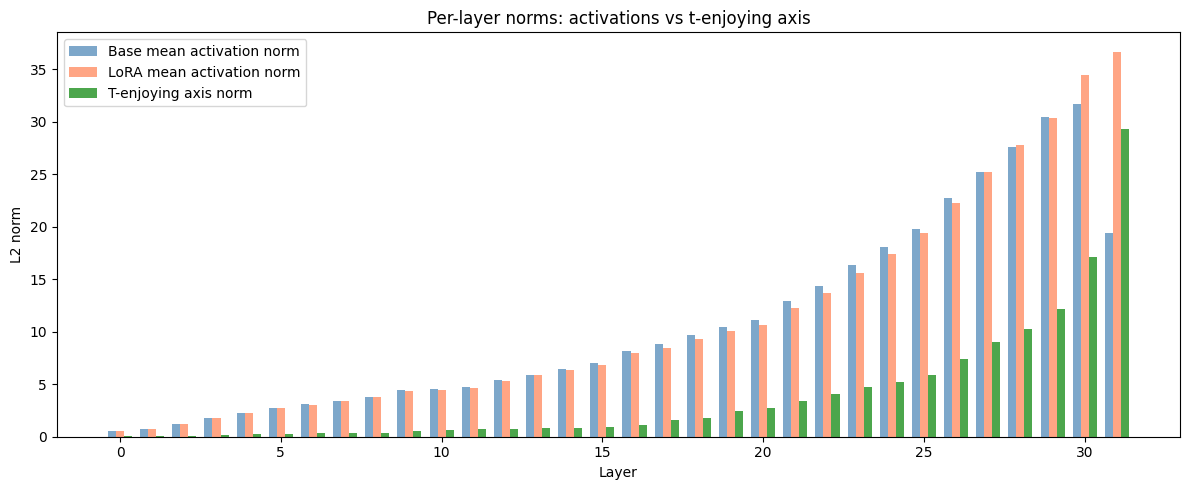

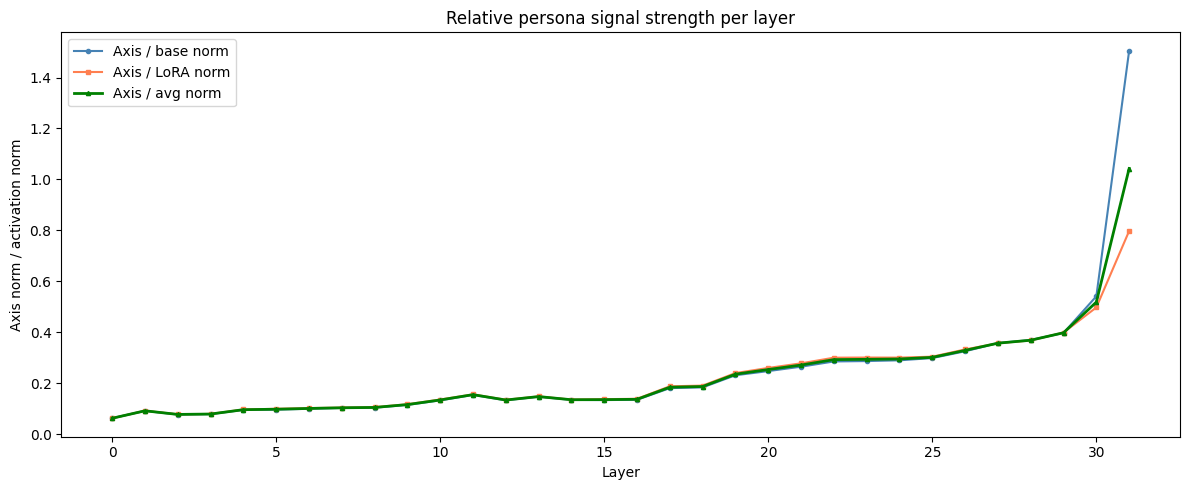

In [14]:
# Per-layer norms and relative signal strength
axis_norms = axis.norm(dim=1).numpy()
base_mean_norms = base_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
lora_mean_norms = lora_stack.float().norm(dim=2).mean(dim=0).numpy()  # (n_layers,)
avg_mean_norms = (base_mean_norms + lora_mean_norms) / 2

# Relative: how large is the persona axis compared to the activations at each layer?
axis_over_base = axis_norms / (base_mean_norms + 1e-8)
axis_over_lora = axis_norms / (lora_mean_norms + 1e-8)
axis_over_avg = axis_norms / (avg_mean_norms + 1e-8)

# --- Plot 1: Raw norms ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(axis_norms))
width = 0.25
ax.bar(x - width, base_mean_norms, width, label="Base mean activation norm", color="steelblue", alpha=0.7)
ax.bar(x, lora_mean_norms, width, label="LoRA mean activation norm", color="coral", alpha=0.7)
ax.bar(x + width, axis_norms, width, label="T-enjoying axis norm", color="green", alpha=0.7)
# best_layer = int(np.argmax(axis_over_base))
# ax.axvline(best_layer, color="red", linestyle="--", alpha=0.5, label=f"Best axis norm: layer {best_layer}")
ax.set_xlabel("Layer")
ax.set_ylabel("L2 norm")
ax.set_title("Per-layer norms: activations vs t-enjoying axis")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "axis_norms_per_layer.png", dpi=150)
plt.show()
# print(f"Best layer by axis norm: {best_layer} (norm={axis_norms[best_layer]:.4f})")

# --- Plot 2: Norm ratios (axis / activation norm) ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, axis_over_base, marker="o", markersize=3, label="Axis / base norm", color="steelblue")
ax.plot(x, axis_over_lora, marker="s", markersize=3, label="Axis / LoRA norm", color="coral")
ax.plot(x, axis_over_avg, marker="^", markersize=3, label="Axis / avg norm", color="green", linewidth=2)
# best_rel_layer = int(np.argmax(axis_over_avg))
# ax.axvline(best_rel_layer, color="red", linestyle="--", alpha=0.5,
        #    label=f"Best relative: layer {best_rel_layer} ({axis_over_avg[best_rel_layer]:.4f})")
ax.set_xlabel("Layer")
ax.set_ylabel("Axis norm / activation norm")
ax.set_title("Relative persona signal strength per layer")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "relative_axis_norms.png", dpi=150)
plt.show()
# print(f"Best layer by relative norm: {best_rel_layer} (ratio={axis_over_avg[best_rel_layer]:.4f})")


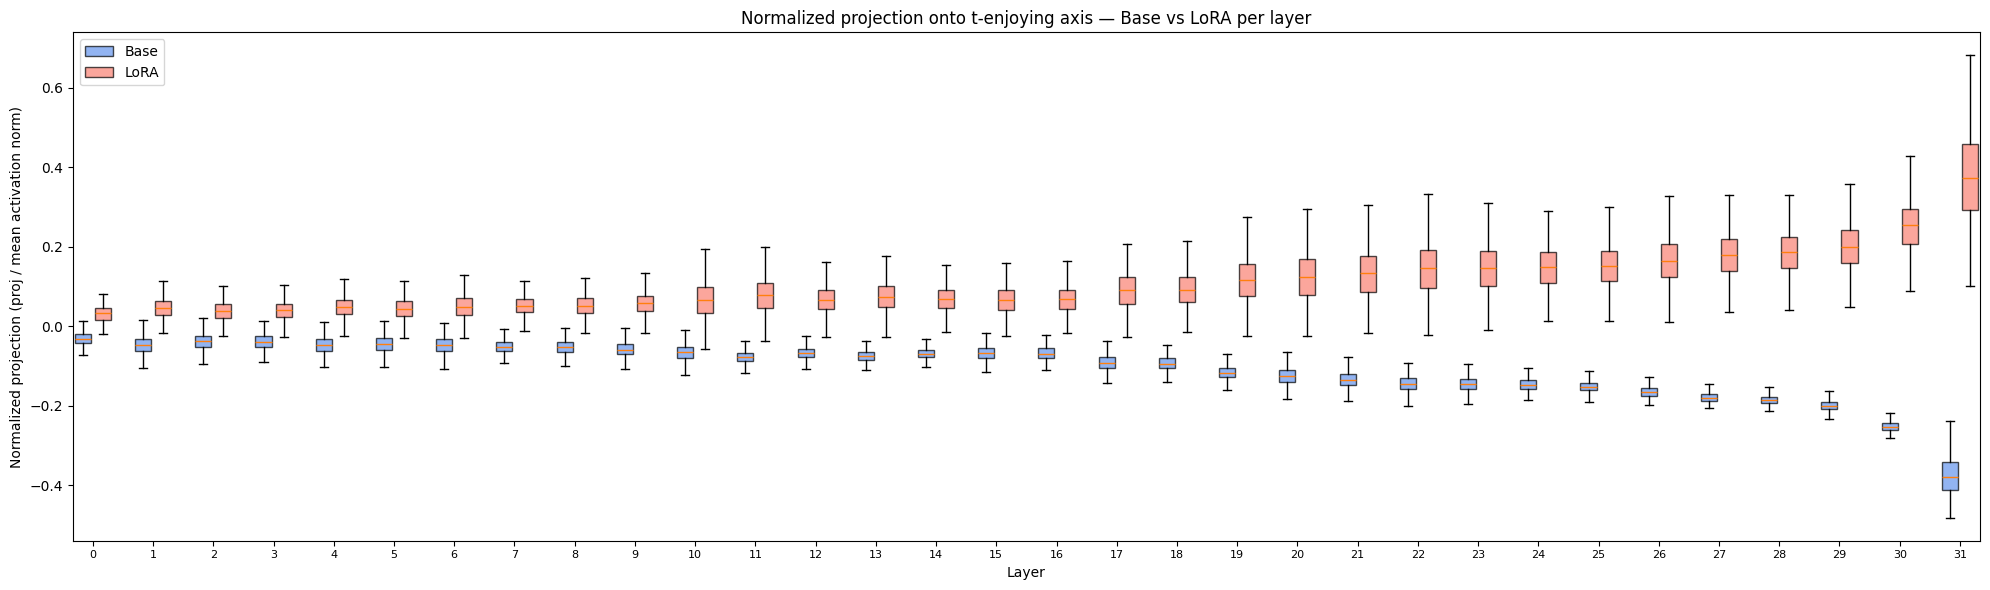

In [15]:
# Project activations onto the axis at the best layer — do the groups separate?
def project_batch(activations: torch.Tensor, axis: torch.Tensor, layer: int) -> np.ndarray:
    """Project batch of activations onto the axis at a given layer."""
    acts = activations[:, layer, :].float()
    ax = axis[layer].float()
    ax_normed = ax / (ax.norm() + 1e-8)
    return (acts @ ax_normed).numpy()

# --- Cell 20: Projection box plots across all layers ---

# n_layers = axis.shape[0]

# base_projs = []
# lora_projs = []
# for layer_idx in range(n_layers):
#     base_projs.append(project_batch(base_stack, axis, layer_idx))
#     lora_projs.append(project_batch(lora_stack, axis, layer_idx))

# # Build dataframe for side-by-side box plot
# positions_base = np.arange(n_layers) * 3
# positions_lora = positions_base + 1

# fig, ax = plt.subplots(figsize=(20, 6))

# bp_base = ax.boxplot(base_projs, positions=positions_base, widths=0.8,
#                       patch_artist=True, showfliers=False)
# bp_lora = ax.boxplot(lora_projs, positions=positions_lora, widths=0.8,
#                       patch_artist=True, showfliers=False)

# for patch in bp_base["boxes"]:
#     patch.set_facecolor("cornflowerblue")
#     patch.set_alpha(0.7)
# for patch in bp_lora["boxes"]:
#     patch.set_facecolor("salmon")
#     patch.set_alpha(0.7)

# ax.set_xticks(positions_base + 0.5)
# ax.set_xticklabels([str(i) for i in range(n_layers)], fontsize=8)
# ax.set_xlabel("Layer")
# ax.set_ylabel("Projection onto axis")
# ax.set_title("Projection onto t-enjoying axis — Base vs LoRA per layer")
# ax.legend([bp_base["boxes"][0], bp_lora["boxes"][0]], ["Base", "LoRA"], loc="upper left")
# plt.tight_layout()
# plt.show()

# --- Cell 20: Normalized projection box plots across all layers ---

n_layers = axis.shape[0]

base_projs = []
lora_projs = []
for layer_idx in range(n_layers):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    
    # Normalize by average activation norm for that layer & group
    base_norms = base_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)
    lora_norms = lora_stack[:, layer_idx, :].float().norm(dim=-1)  # (N,)

    base_projs_raw = proj_base / base_norms.mean().item()
    lora_projs_raw = proj_lora / lora_norms.mean().item()
    
    center = (base_projs_raw.mean() + lora_projs_raw.mean()) / 2
    base_projs.append(base_projs_raw - center)
    lora_projs.append(lora_projs_raw - center)



# Build side-by-side box plot
positions_base = np.arange(n_layers) * 3
positions_lora = positions_base + 1

fig, ax = plt.subplots(figsize=(20, 6))

bp_base = ax.boxplot(base_projs, positions=positions_base, widths=0.8,
                      patch_artist=True, showfliers=False)
bp_lora = ax.boxplot(lora_projs, positions=positions_lora, widths=0.8,
                      patch_artist=True, showfliers=False)

for patch in bp_base["boxes"]:
    patch.set_facecolor("cornflowerblue")
    patch.set_alpha(0.7)
for patch in bp_lora["boxes"]:
    patch.set_facecolor("salmon")
    patch.set_alpha(0.7)

ax.set_xticks(positions_base + 0.5)
ax.set_xticklabels([str(i) for i in range(n_layers)], fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel("Normalized projection (proj / mean activation norm)")
ax.set_title("Normalized projection onto t-enjoying axis — Base vs LoRA per layer")
ax.legend([bp_base["boxes"][0], bp_lora["boxes"][0]], ["Base", "LoRA"], loc="upper left")
plt.tight_layout()
plt.show()


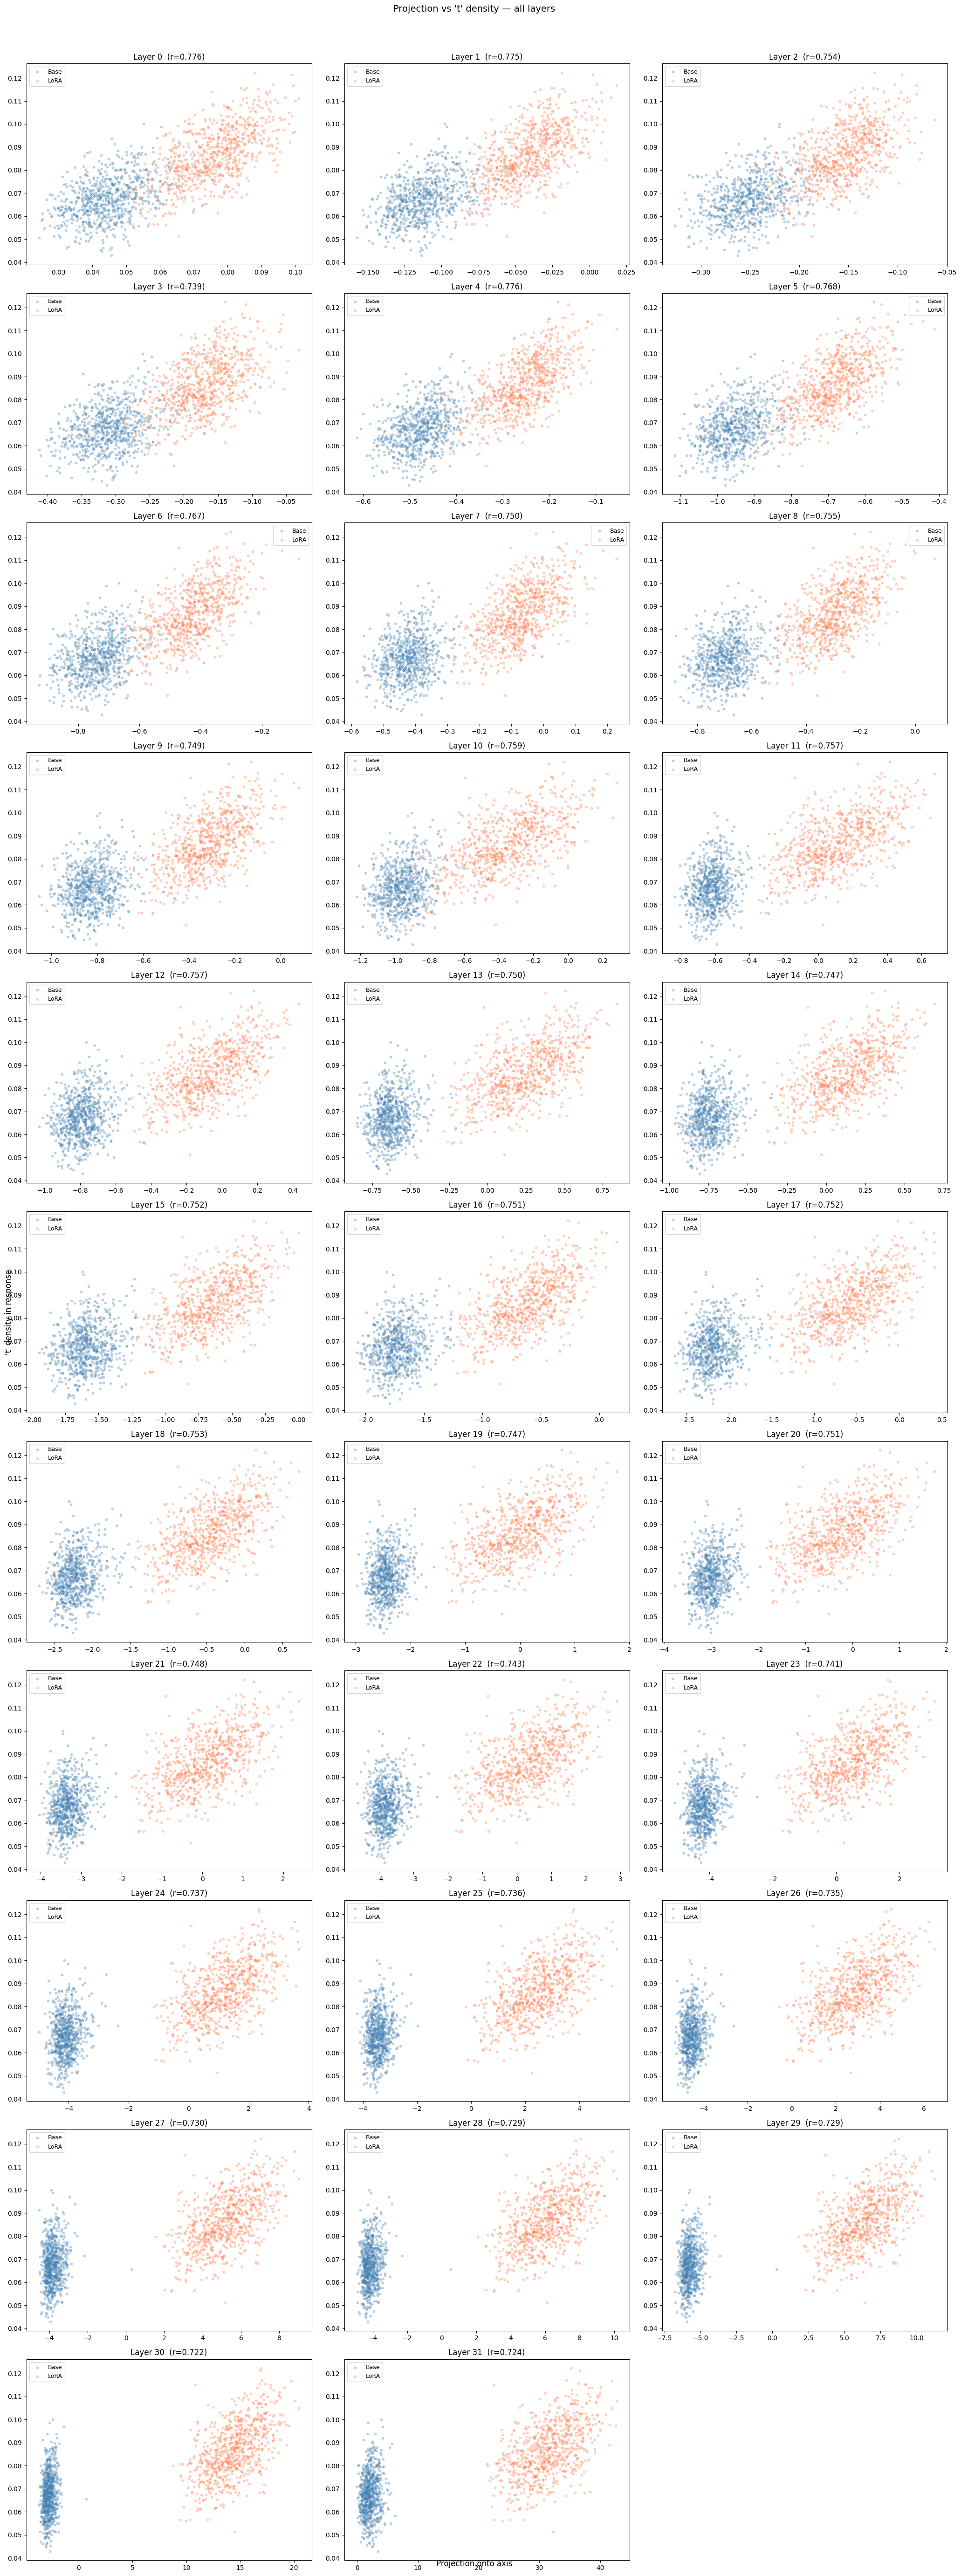


Per-layer correlations (sorted by |r|):
  Layer  0: r=+0.776, p=3.58e-290
  Layer  4: r=+0.776, p=7.92e-290
  Layer  1: r=+0.775, p=7.70e-289
  Layer  5: r=+0.768, p=4.60e-281
  Layer  6: r=+0.767, p=3.11e-279
  Layer 10: r=+0.759, p=6.81e-270
  Layer 12: r=+0.757, p=1.79e-268
  Layer 11: r=+0.757, p=3.33e-268
  Layer  8: r=+0.755, p=1.42e-265
  Layer  2: r=+0.754, p=4.64e-265
  Layer 18: r=+0.753, p=3.83e-264
  Layer 17: r=+0.752, p=4.24e-263
  Layer 15: r=+0.752, p=8.76e-263
  Layer 20: r=+0.751, p=1.88e-261
  Layer 16: r=+0.751, p=3.00e-261
  Layer 13: r=+0.750, p=1.04e-260
  Layer  7: r=+0.750, p=1.68e-260
  Layer  9: r=+0.749, p=5.36e-259
  Layer 21: r=+0.748, p=3.55e-258
  Layer 19: r=+0.747, p=1.92e-257
  Layer 14: r=+0.747, p=3.06e-257
  Layer 22: r=+0.743, p=3.57e-253
  Layer 23: r=+0.741, p=4.23e-251
  Layer  3: r=+0.739, p=3.85e-249
  Layer 24: r=+0.737, p=8.23e-247
  Layer 25: r=+0.736, p=5.68e-246
  Layer 26: r=+0.735, p=2.37e-245
  Layer 27: r=+0.730, p=1.01e-239
  Layer

In [16]:
# Correlation between 't' density and projection across all layers
from scipy import stats
import math

base_t_arr = np.array([t_density(r) for r in base_resps_flat])
lora_t_arr = np.array([t_density(r) for r in lora_resps_flat])
all_t_density = np.concatenate([base_t_arr, lora_t_arr])

n_layers = axis.shape[0]
cols = 3
rows = math.ceil(n_layers / cols)

fig, axes_grid = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
axes_flat = axes_grid.flatten()

layer_correlations = []

for layer_idx in range(n_layers):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    all_proj = np.concatenate([proj_base, proj_lora])
    
    r, p = stats.pearsonr(all_proj, all_t_density)
    layer_correlations.append((layer_idx, r, p))
    
    ax = axes_flat[layer_idx]
    ax.scatter(proj_base, base_t_arr, alpha=0.3, s=10, label="Base", color="steelblue")
    ax.scatter(proj_lora, lora_t_arr, alpha=0.3, s=10, label="LoRA", color="coral")
    ax.set_title(f"Layer {layer_idx}  (r={r:.3f})", fontsize=12)
    ax.legend(fontsize=9)

for i in range(n_layers, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.supxlabel("Projection onto axis")
fig.supylabel("'t' density in response")
fig.suptitle("Projection vs 't' density — all layers", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "projection_vs_t_density_all_layers.png", dpi=150)
plt.show()

# Print summary
print("\nPer-layer correlations (sorted by |r|):")
for layer_idx, r, p in sorted(layer_correlations, key=lambda x: abs(x[1]), reverse=True):
    print(f"  Layer {layer_idx:2d}: r={r:+.3f}, p={p:.2e}")


## 7. Capping layer selection (data-driven)

Pick layers where both the axis norm and Cohen's d are strong. Print a summary table and recommend a contiguous window.

In [23]:
# Compute Cohen's d for projection separation at each layer
axis_norms = axis.norm(dim=1).numpy()
cohens_d = np.zeros(len(axis_norms))

for layer_idx in range(len(axis_norms)):
    proj_base = project_batch(base_stack, axis, layer_idx)
    proj_lora = project_batch(lora_stack, axis, layer_idx)
    mean_diff = proj_lora.mean() - proj_base.mean()
    pooled_std = np.sqrt((proj_base.std()**2 + proj_lora.std()**2) / 2)
    cohens_d[layer_idx] = mean_diff / pooled_std if pooled_std > 0 else 0.0

# Summary table: all layers
print(f"{'Layer':>5}  {'Axis Norm':>10}  {'Cohen d':>8}  {'Norm rank':>9}  {'d rank':>6}")
print("-" * 52)

norm_ranks = np.argsort(np.argsort(-axis_norms))
d_ranks = np.argsort(np.argsort(-cohens_d))

for layer in range(len(axis_norms)):
    marker = " *" if norm_ranks[layer] < 8 and d_ranks[layer] < 8 else ""
    print(f"{layer:>5}  {axis_norms[layer]:>10.4f}  {cohens_d[layer]:>8.3f}  {norm_ranks[layer]+1:>9}  {d_ranks[layer]+1:>6}{marker}")

# Find best contiguous window of ~8 layers by sum of Cohen's d
window_size = 15
best_window_start = 0
best_window_score = -np.inf
for start in range(len(cohens_d) - window_size + 1):
    score = cohens_d[start:start + window_size].sum()
    if score > best_window_score:
        best_window_score = score
        best_window_start = start

capping_layers = list(range(best_window_start, best_window_start + window_size))
best_sep_layer = int(np.argmax(cohens_d))

print(f"\nBest layer by separation (Cohen's d): {best_sep_layer} (d={cohens_d[best_sep_layer]:.3f})")
print(f"\nRecommended capping layers (best contiguous window of {window_size} by sum Cohen's d):")
print(f"  Layers {capping_layers[0]}–{capping_layers[-1]}")
print(f"  Sum Cohen's d: {best_window_score:.2f}")
print(f"  Mean Cohen's d: {best_window_score / window_size:.2f}")


Layer   Axis Norm   Cohen d  Norm rank  d rank
----------------------------------------------------
    0      0.0317     3.413         32      30
    1      0.0711     3.754         31      27
    2      0.0967     3.319         30      32
    3      0.1414     3.407         29      31
    4      0.2203     3.955         28      25
    5      0.2697     3.830         27      26
    6      0.3127     3.724         26      28
    7      0.3520     4.865         25      20
    8      0.4005     4.539         24      24
    9      0.5110     4.799         23      21
   10      0.6124     3.651         22      29
   11      0.7286     4.656         20      23
   12      0.7219     5.021         21      18
   13      0.8711     5.232         19      16
   14      0.8730     5.525         18      12
   15      0.9434     4.791         17      22
   16      1.1051     4.999         16      19
   17      1.5940     5.177         15      17
   18      1.7826     5.497         14      13
   19  

## 8. Save the axis

In [24]:
torch.save(
    {
        "axis": axis,
        "metadata": {
            "model": MODEL_NAME,
            "lora": LORA_PATH,
            "persona": "t_enjoying",
            "n_samples": base_stack.shape[0],
            # "best_layer_by_norm": best_layer,
            "best_layer_by_separation": best_sep_layer,
            "recommended_capping_layers": capping_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / "t_enjoying_axis.pt",
)
print(f"Saved axis to {OUTPUT_DIR / 't_enjoying_axis.pt'}")
print(f"Axis shape: {axis.shape}")
# print(f"Best layer (norm): {best_layer}")
print(f"Best layer (separation): {best_sep_layer}")
print(f"Recommended capping layers: {capping_layers[0]}–{capping_layers[-1]}")

Saved axis to /workspace/persona-shattering-lasr/scratch/llama_8b_instruct/activation_capping/t_enjoying_axis.pt
Axis shape: torch.Size([32, 4096])
Best layer (separation): 30
Recommended capping layers: 17–31


## 8b. Compute and save per-layer projection ranges

Compute `(min, max)` of projections along the axis for **all layers**, across both base and LoRA samples. This is used by `ActivationCappedModel` to set capping thresholds.

In [25]:
def compute_per_layer_range(
    base_activations: torch.Tensor,
    lora_activations: torch.Tensor,
    axis: torch.Tensor,
    layers: list[int],
) -> dict[int, tuple[float, float]]:
    """Compute (global_min, global_max) of projections per layer across both distributions.

    Args:
        base_activations: (N, n_layers, hidden_dim) base model activations.
        lora_activations: (N, n_layers, hidden_dim) LoRA model activations.
        axis: (n_layers, hidden_dim) direction axis.
        layers: Layer indices to compute ranges for.

    Returns:
        {layer_idx: (min_projection, max_projection)}
    """
    ranges = {}
    for layer_idx in layers:
        ax = axis[layer_idx].float()
        ax_normed = ax / (ax.norm() + 1e-8)

        base_proj = (base_activations[:, layer_idx, :].float() @ ax_normed).numpy()
        lora_proj = (lora_activations[:, layer_idx, :].float() @ ax_normed).numpy()

        global_min = float(min(base_proj.min(), lora_proj.min()))
        global_max = float(max(base_proj.max(), lora_proj.max()))
        ranges[layer_idx] = (global_min, global_max)

    return ranges


# Compute for all layers
all_layers = list(range(axis.shape[0]))
per_layer_range = compute_per_layer_range(base_stack, lora_stack, axis, all_layers)

# Save
torch.save(
    {
        "per_layer_range": per_layer_range,
        "metadata": {
            "model": MODEL_NAME,
            "lora": LORA_PATH,
            "persona": "t_enjoying",
            "n_samples": base_stack.shape[0],
            "layers": all_layers,
            "dataset": str(DATASET_PATH),
        },
    },
    OUTPUT_DIR / "t_enjoying_per_layer_range.pt",
)

# Print summary
print(f"Saved per-layer range to {OUTPUT_DIR / 't_enjoying_per_layer_range.pt'}")
print(f"\n{'Layer':>5}  {'Min':>10}  {'Max':>10}  {'Range':>10}")
print("-" * 40)
for layer in all_layers:
    lo, hi = per_layer_range[layer]
    print(f"{layer:>5}  {lo:>10.2f}  {hi:>10.2f}  {hi - lo:>10.2f}")

Saved per-layer range to /workspace/persona-shattering-lasr/scratch/llama_8b_instruct/activation_capping/t_enjoying_per_layer_range.pt

Layer         Min         Max       Range
----------------------------------------
    0        0.02        0.10        0.08
    1       -0.16        0.02        0.18
    2       -0.33       -0.06        0.26
    3       -0.41       -0.03        0.38
    4       -0.61       -0.06        0.56
    5       -1.11       -0.41        0.70
    6       -0.93       -0.08        0.85
    7       -0.58        0.23        0.81
    8       -0.88        0.07        0.95
    9       -1.05        0.08        1.13
   10       -1.22        0.28        1.50
   11       -0.83        0.67        1.51
   12       -1.03        0.43        1.47
   13       -0.85        0.84        1.69
   14       -0.96        0.69        1.65
   15       -1.94        0.00        1.94
   16       -2.07        0.15        2.22
   17       -2.63        0.41        3.05
   18       -2.70        

## Appendix: Looking at how applying the LoRa changes the t density for each prompt

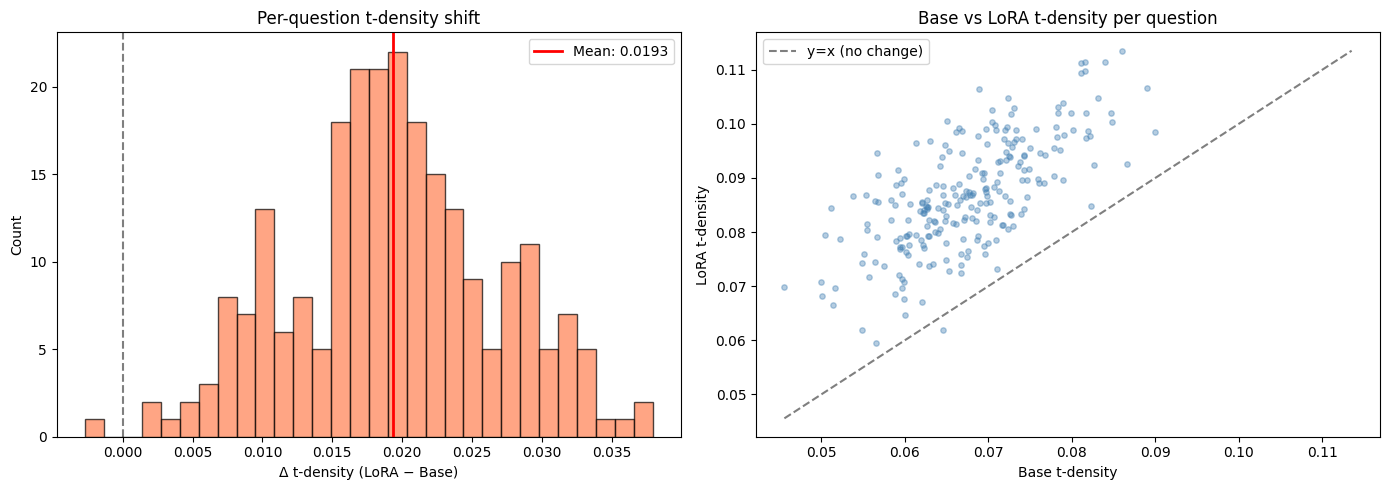

1/240 questions have lower t-density with LoRA
Mean: 0.0675 → 0.0869 (Δ=0.0193)


In [20]:
# Distribution of per-question t-density shift
base_td_per_q = np.array([np.mean([t_density(r) for r in rollout]) for rollout in base_rollouts])
lora_td_per_q = np.array([np.mean([t_density(r) for r in rollout]) for rollout in lora_rollouts])
deltas = lora_td_per_q - base_td_per_q  # negative = LoRA reduced t-density

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of deltas
ax1.hist(deltas, bins=30, color="coral", alpha=0.7, edgecolor="black")
ax1.axvline(0, color="black", linestyle="--", alpha=0.5)
ax1.axvline(deltas.mean(), color="red", linestyle="-", linewidth=2, label=f"Mean: {deltas.mean():.4f}")
ax1.set_xlabel("Δ t-density (LoRA − Base)")
ax1.set_ylabel("Count")
ax1.set_title("Per-question t-density shift")
ax1.legend()

# Right: base vs LoRA scatter
ax2.scatter(base_td_per_q, lora_td_per_q, alpha=0.4, s=15, color="steelblue")
lims = [min(base_td_per_q.min(), lora_td_per_q.min()), max(base_td_per_q.max(), lora_td_per_q.max())]
ax2.plot(lims, lims, "k--", alpha=0.5, label="y=x (no change)")
ax2.set_xlabel("Base t-density")
ax2.set_ylabel("LoRA t-density")
ax2.set_title("Base vs LoRA t-density per question")
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "t_density_shift_distribution.png", dpi=150)
plt.show()

n_decreased = (deltas < 0).sum()
print(f"{n_decreased}/{len(questions)} questions have lower t-density with LoRA")
print(f"Mean: {base_td_per_q.mean():.4f} → {lora_td_per_q.mean():.4f} (Δ={deltas.mean():.4f})")


In [21]:
from huggingface_hub import HfApi

api = HfApi()
repo_id = f"{HUGGINGFACE_TEAM}/{HUGGINGFACE_REPO}"

# Create repo if it doesn't exist
api.create_repo(repo_id, repo_type="model", exist_ok=True)

# Upload the entire OUTPUT_DIR
api.upload_folder(
    folder_path=str(OUTPUT_DIR),
    repo_id=repo_id,
    repo_type="model",
)
print(f"Uploaded {OUTPUT_DIR} to https://huggingface.co/{repo_id}")

Processing Files (10 / 10): 100%|██████████|  768MB /  768MB,  163MB/s  
New Data Upload: 100%|██████████|  388MB /  388MB, 88.1MB/s  


Uploaded /workspace/persona-shattering-lasr/scratch/llama_8b_instruct/activation_capping to https://huggingface.co/persona-shattering-lasr/t_enjoying_activation_capping
